# NaiveBayes & SVM using TF-IDF Benchmark - Symptoms Disease Classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

os.makedirs("./results/naive_bayes", exist_ok=True)
os.makedirs("./results/svm", exist_ok=True)

c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

In [2]:
ds = load_dataset("ninaa510/diagnosis-text")

train_ds = ds["train"].rename_column("sentence1", "text").class_encode_column("label")
test_ds = ds["test"].rename_column("sentence1", "text").class_encode_column("label")

train_ds

Dataset({
    features: ['label', 'text'],
    num_rows: 13310
})

In [3]:
train_ds[0]

{'label': 0,
 'text': 'I am a 12-year-old male with an itchy nose, sharp upper abdominal pain, pink skin lesions or rashes on my neck, swelling in my nose, had an allergic reaction, and experiencing high-pitched breathing sounds, lightheadedness, and wheezing on exhale.'}

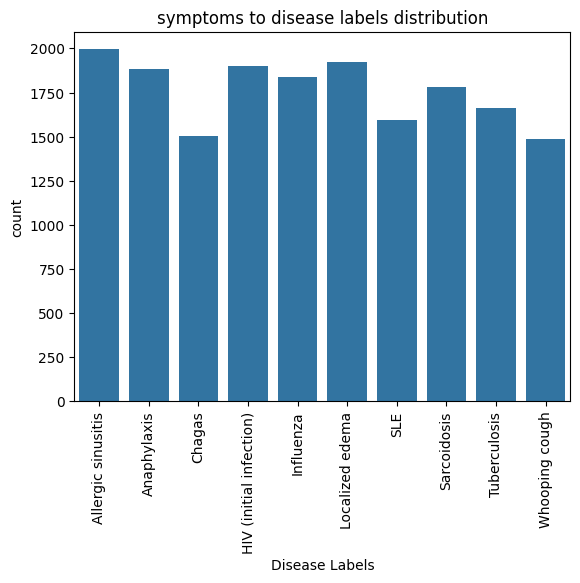

In [4]:
train = pd.DataFrame(ds["train"])
test = pd.DataFrame(ds["test"])

df = pd.concat([train, test], ignore_index=True)

sns.countplot(data=df, x="label")
plt.title("symptoms to disease labels distribution")
plt.xlabel("Disease Labels")
plt.xticks(rotation=90)
plt.ylabel("count")
plt.show()

In [6]:
X_train = train_ds["text"]
y_train = train_ds["label"]
X_test  = test_ds["text"]
y_test  = test_ds["label"]

total_labels = len(set(train_ds["label"]))
id2label = dict(enumerate(train_ds.features["label"].names))
label2id = {v: k for k, v in id2label.items()}

print(f"Train size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")
print(f"Num classes: {total_labels}")

Train size : 13310
Test size  : 4262
Num classes: 10


## TF-IDF Vectorizer

In [7]:
tfidf = TfidfVectorizer(
    sublinear_tf=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=50_000,
)

# Fit on training data only — same principle as fitting tokenizer on train split
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test) : {X_test_tfidf.shape}")

TF-IDF matrix shape (train): (13310, 5900)
TF-IDF matrix shape (test) : (4262, 5900)


In [8]:
def evaluate(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")
    print(f"[{model_name}]  accuracy: {acc:.4f} | f1 (weighted): {f1:.4f}")
    return acc, f1

def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.show()

def show_report(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    return df_report

## Naive Bayes Model

In [9]:
nb_model = ComplementNB(alpha=0.1)   # alpha: Laplace smoothing
nb_model.fit(X_train_tfidf, y_train)

nb_preds = nb_model.predict(X_test_tfidf)
nb_acc, nb_f1 = evaluate("Naive Bayes", y_test, nb_preds)

[Naive Bayes]  accuracy: 0.5049 | f1 (weighted): 0.4943


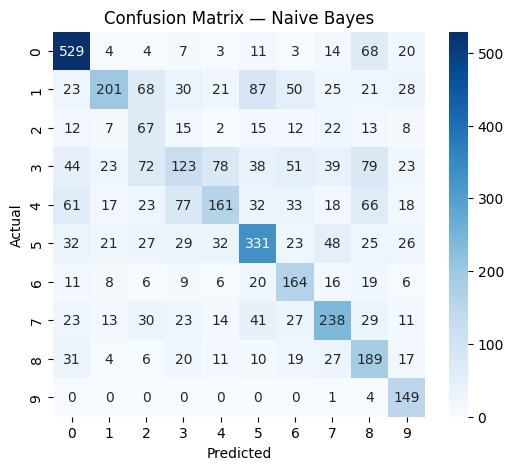

In [10]:
plot_confusion_matrix("Naive Bayes", y_test, nb_preds)

In [11]:
show_report(y_test, nb_preds)

,precision,recall,f1-score,support
0,0.690601,0.797888,0.740378,663.000000
1,0.674497,0.362816,0.471831,554.000000
2,0.221122,0.387283,0.281513,173.000000
3,0.369369,0.215789,0.272425,570.000000
4,0.490854,0.318182,0.386091,506.000000
5,0.565812,0.557239,0.561493,594.000000
6,0.429319,0.618868,0.506955,265.000000
7,0.531250,0.530067,0.530658,449.000000
8,0.368421,0.565868,0.446281,334.000000
9,0.486928,0.967532,0.647826,154.000000


In [12]:
joblib.dump(nb_model, "./results/naive_bayes/model.pkl")
joblib.dump(tfidf,    "./results/naive_bayes/tfidf.pkl")

['./results/naive_bayes/tfidf.pkl']

## Support Vector Machine (SVM) Model

In [13]:
svm_base = LinearSVC(C=1.0, max_iter=2000)
svm_model = CalibratedClassifierCV(svm_base, cv=3)   # adds .predict_proba()
svm_model.fit(X_train_tfidf, y_train)

svm_preds = svm_model.predict(X_test_tfidf)
svm_acc, svm_f1 = evaluate("SVM", y_test, svm_preds)

[SVM]  accuracy: 0.5516 | f1 (weighted): 0.5492


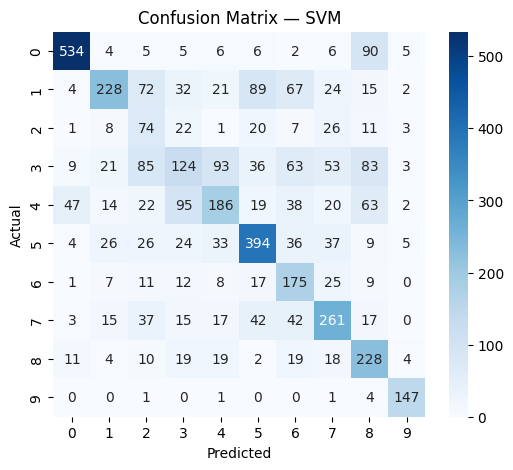

In [14]:
plot_confusion_matrix("SVM", y_test, svm_preds)

In [15]:
show_report(y_test, svm_preds)

,precision,recall,f1-score,support
0,0.869707,0.805430,0.836335,663.000000
1,0.697248,0.411552,0.517594,554.000000
2,0.215743,0.427746,0.286822,173.000000
3,0.356322,0.217544,0.270153,570.000000
4,0.483117,0.367589,0.417508,506.000000
5,0.630400,0.663300,0.646432,594.000000
6,0.389755,0.660377,0.490196,265.000000
7,0.554140,0.581292,0.567391,449.000000
8,0.431002,0.682635,0.528389,334.000000
9,0.859649,0.954545,0.904615,154.000000


In [16]:
joblib.dump(svm_model, "./results/svm/model.pkl")
joblib.dump(tfidf,     "./results/svm/tfidf.pkl")

['./results/svm/tfidf.pkl']

## Inference Example

In [17]:
import joblib, json

nb_model  = joblib.load("./results/naive_bayes/model.pkl")
svm_model = joblib.load("./results/svm/model.pkl")
tfidf     = joblib.load("./results/naive_bayes/tfidf.pkl")  # same vectorizer for both

def predict(text, model, label_map):
    vec   = tfidf.transform([text])
    pred  = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0]
    return [{"label": label_map[pred], "score": round(float(proba[pred]), 4)}]

test_text = "i have itchy nose, and i dont feel well"

print("Naive Bayes:", predict(test_text, nb_model,  id2label))
print("SVM        :", predict(test_text, svm_model, id2label))

Naive Bayes: [{'label': 'Allergic sinusitis', 'score': 0.125}]
SVM        : [{'label': 'Allergic sinusitis', 'score': 0.7067}]
